In [1]:
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import copy
import math
import time

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch.linalg import norm

from common.optim.meta import MetaData
from common.optim.exp.netline_scheduler_v2qq_samplealpha import NetLineStepLR
from common.optim.nn import CrossEntropyKappaBalancedLoss
from common.util import get_meters, test_loop
from common.cnn import make_resnet18v2
from common.lr_scheduling import cosine_range_annealing2_lr, cosine_annealing2_lr, cosine_annealing3_lr, line_annealing4_lr, line_annealing2_lr, \
    cosine_annealing4_lr, line_cosine_annealing4_lr, line_annealing3_lr

from torchvision.datasets import CIFAR100
from torchvision import transforms
from common.optim.optimizer_pack1 import Lookahead

import logging

In [2]:
logging.basicConfig(filename="logs/cifar100_restnet18.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")


#### Constants

In [3]:
BATCH_SIZE = 128
SAMPLE_SIZE = 1024
OUTPUT_DIM = 100
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

EXPERIMENTS = 1
EPOCHS_PER_EXPERIMENT = 60
DATASET_PATH = "./datasets"


#### Manual seed

In [4]:
'''
seed_value= 641

# 1. Set `PYTHONHASHSEED` environment variable at a fixed value
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set `python` built-in pseudo-random generator at a fixed value
random.seed(seed_value)
# 3. Set `numpy` pseudo-random generator at a fixed value
np.random.seed(seed_value)
# 4. Set `pytorch` pseudo-random generator at a fixed value
dummy=torch.manual_seed(seed_value)
'''

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = False
#torch.backends.cuda.matmul.fp32_precision = 'ieee'

# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = False
#torch.backends.cudnn.conv.fp32_precision = 'tf32'


#### CIFAR10 dataset

In [5]:
# Data transforms (normalization & data augmentation)
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_transforms = transforms.Compose([transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
                         transforms.RandomHorizontalFlip(),
                         transforms.ToTensor(),
                         transforms.Normalize(*stats,inplace=True)])
valid_transforms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(*stats)])

train_dataset = CIFAR100(root=DATASET_PATH, train=True, download=True, transform=train_transforms)
test_dataset = CIFAR100(root=DATASET_PATH, train=False, download=True, transform=valid_transforms)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=1024, num_workers=0, pin_memory=True)

d:\Programs-python\Python314\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


##### UTILS

In [6]:
def experiment_comparison(data, low, high, title="Comparison"):

    MEAN_ADAM = data[low:high,0]
    MEAN_NETLINE = data[low:high,1]
    MEAN_SGD = data[low:high,2]
    cord_x = np.arange(0, len(MEAN_NETLINE[:,22]))

    #display.clear_output()
    fig, axes = plt.subplots(5, 2, figsize=(18, 24))
    axes[0,0].set_title('Loss (average cross entropy) per epoch')
    axes[0,0].plot(MEAN_ADAM[:,1], color='g',alpha=.5, label='Lookahead')
    axes[0,0].plot(MEAN_NETLINE[:,1], color='b',alpha=.5, label='Net-line')
    axes[0,0].plot(MEAN_SGD[:,1], color='grey', alpha=.5, label='SGD')
    axes[0,0].grid()
    axes[0,0].set_yscale("log")
    axes[0,0].legend()
    axes[0,0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0,0].set_ylabel("Loss value")

    axes[0,1].set_title('Error (top 1) mean per epoch')
    axes[0,1].plot(1.0-MEAN_ADAM[:,0], color='g', alpha=.5, label='Lookahead')
    axes[0,1].plot(1.0-MEAN_NETLINE[:,0], color='b', alpha=.5, label='Net-line')
    axes[0,1].plot(1.0-MEAN_SGD[:,0], color='grey', alpha=.5, label='SGD')
    axes[0,1].grid()
    axes[0,1].set_yscale("log")
    axes[0,1].legend()
    axes[0,1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0,1].set_ylabel("Error value")

    axes[1,0].set_title('PQ and PQ1 norm mean per epoch')
    axes[1,0].plot(MEAN_ADAM[:,4], color='g',alpha=.5, label='PQ norm, Lookahead')
    axes[1,0].plot(MEAN_NETLINE[:,4], color='b',alpha=.5, label='PQ norm, Net-line')
    axes[1,0].fill_between(x=cord_x, y1=MEAN_NETLINE[:,4]-MEAN_NETLINE[:,12], y2=MEAN_NETLINE[:,4]+MEAN_NETLINE[:,12], color='b', alpha=.125)
    axes[1,0].plot(MEAN_SGD[:,4], color='grey',alpha=.5, label='PQ norm, SGD')
    axes[1,0].plot(MEAN_ADAM[:,7], color='g',alpha=.5, linestyle='dashed', label='PQ1 norm, Lookahead')
    axes[1,0].plot(MEAN_NETLINE[:,7], color='b',alpha=.5, linestyle='dashed', label='PQ1 norm, Net-line')
    axes[1,0].plot(MEAN_SGD[:,7], color='grey',alpha=.5, linestyle='dashed', label='PQ1 norm, SGD')
    axes[1,0].grid()
    axes[1,0].legend()

    axes[1,1].set_title('QQ1 vector norm mean per epoch')
    axes[1,1].set_yscale("log")
    axes[1,1].plot(MEAN_NETLINE[:,3], color='orange',alpha=.5, linestyle='dashed',label='QQ1 vector norm/eta1, Net-line')
    axes[1,1].plot(MEAN_ADAM[:,10], color='g',alpha=.5, label='QQ2 vector norm/eta2, Lookahead')
    axes[1,1].plot(MEAN_NETLINE[:,10], color='b',alpha=.5, label='QQ2 vector norm/eta2, Net-line')
    axes[1,1].plot(MEAN_SGD[:,10], color='grey',alpha=.5, label='QQ2 vector norm/eta2, SGD')
    axes[1,1].grid()
    axes[1,1].legend()

    axes[2,0].set_title('Cos phi and alpha mean per epoch')
    axes[2,0].plot(MEAN_ADAM[:,5], color='g',alpha=.5, label='Cos phi, Lookahead')
    axes[2,0].plot(MEAN_NETLINE[:,5], color='b',alpha=.5, label='Cos phi, Net-line')
    axes[2,0].fill_between(x=cord_x, y1=MEAN_NETLINE[:,5]-MEAN_NETLINE[:,13], y2=MEAN_NETLINE[:,5]+MEAN_NETLINE[:,13], color='b', alpha=.125)
    axes[2,0].plot(MEAN_SGD[:,5], color='grey',alpha=.5, label='Cos phi, SGD')
    axes[2,0].plot(MEAN_NETLINE[:,15], color='magenta',alpha=.5, label='Alpha summary, Net-line')
    axes[2,0].grid()
    axes[2,0].legend()

    axes[2,1].set_title('Eta calculated')
    axes[2,1].set_yscale("log")
    axes[2,1].plot(MEAN_NETLINE[:,6], color='red', linestyle='dashed', alpha=.5, label='Eta2 averaged mean per epoch')
    axes[2,1].plot(MEAN_NETLINE[:,21], color='blue',alpha=.5, label='Eta2 no-averaged mean plus-minus one sigma per epoch')
    axes[2,1].fill_between(x=cord_x, y1=MEAN_NETLINE[:,21]-MEAN_NETLINE[:,22], y2=MEAN_NETLINE[:,21]+MEAN_NETLINE[:,22], color='blue', alpha=.125)
    axes[2,1].plot(MEAN_NETLINE[:,11], color='magenta', alpha=.25, label='eta_base')

    axes[2,1].plot(MEAN_SGD[:,6], color='grey', alpha=.5, label='Eta SGD mean per epoch')
    axes[2,1].grid()
    axes[2,1].legend()

    x3 = MEAN_NETLINE[:,3]
    deltas = [0]+[(next_val - current_val)/current_val for current_val, next_val in zip(x3, x3[1:])]

    axes[3,0].set_title('QQ1 dynamics')
    #axes[3,0].set_yscale("log")
    axes[3,0].plot(MEAN_NETLINE[:,18], color='green',alpha=.5, label='Regression beta-coeff mean per epoch')
    axes[3,0].plot(deltas, color='red',alpha=.5, label='QQ1 average per epoch relative change')
    axes[3,0].grid()
    axes[3,0].legend()

    axes[3,1].set_title('Alpha-nonmomentum and speed ratio')
    #axes[3,1].set_yscale("log")
    axes[3,1].plot(MEAN_NETLINE[:,9], color='green',alpha=.5, label='alpha-nonmomentum mean per epoch')
    axes[3,1].fill_between(x=cord_x, y1=MEAN_NETLINE[:,9]-MEAN_NETLINE[:,14], y2=MEAN_NETLINE[:,9]+MEAN_NETLINE[:,14], color='green', alpha=.125)
    axes[3,1].plot(MEAN_NETLINE[:,16], color='red',alpha=.5, label='speed ratio per epoch')
    axes[3,1].grid()
    axes[3,1].legend()

    axes[4,0].set_title('Passed lr ratio mean per epoch')
    #axes[4,0].set_yscale("log")
    axes[4,0].plot(MEAN_ADAM[:,8], color='g',alpha=.5, label='Lookahead')
    axes[4,0].plot(MEAN_NETLINE[:,8], color='b',alpha=.5, label='Net-line')
    axes[4,0].plot(MEAN_SGD[:,8], color='grey',alpha=.5, label='Sgd')
    axes[4,0].grid()
    axes[4,0].legend()

    axes[4,1].set_title('Cos psi mean per epoch')
    #axes[4,1].set_yscale("log")
    axes[4,1].plot(MEAN_ADAM[:,17], color='g',alpha=.5, label='Lookahead')
    axes[4,1].plot(MEAN_NETLINE[:,17], color='b',alpha=.5, label='Net-line')
    axes[4,1].plot(MEAN_SGD[:,17], color='grey',alpha=.5, label='Sgd')
    axes[4,1].grid()
    axes[4,1].legend()

    dummy=fig.suptitle(title)
    plt.show()

def experiments_comparison(data, std, low, high, title="Comparison"):

    MEAN_ADAM = data[low:high,0]
    MEAN_NETLINE = data[low:high,1]
    MEAN_SGD = data[low:high,2]
    lowB, upB = data[low:high]-std[low:high], data[low:high]+std[low:high]
    LOW_ADAM, UP_ADAM = lowB[:,0], upB[:,0]
    LOW_NETLINE, UP_NETLINE = lowB[:,1], upB[:,1]
    LOW_SGD, UP_SGD = lowB[:,2], upB[:,2]
    cord_x = np.arange(0, len(MEAN_ADAM[:,1]))

    #display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    axes[0].set_title('Loss (average cross entropy)')
    axes[0].plot(MEAN_ADAM[:,1], color='g',alpha=.5, label='Lookahead')
    if (std is not None):
        axes[0].fill_between(x=cord_x, y1=LOW_ADAM[:,1], y2=UP_ADAM[:,1], color='g', alpha=.125)
    axes[0].plot(MEAN_NETLINE[:,1], color='b',alpha=.5, label='Net-line')
    if (std is not None):
        axes[0].fill_between(x=cord_x, y1=LOW_NETLINE[:,1], y2=UP_NETLINE[:,1], color='b', alpha=.125)
    axes[0].plot(MEAN_SGD[:,1], color='grey', alpha=.5, label='SGD')
    if (std is not None):
        axes[0].fill_between(x=cord_x, y1=LOW_SGD[:,1], y2=UP_SGD[:,1], color='grey', alpha=.125)
    axes[0].grid()
    axes[0].set_yscale("log")
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Error (top 1)')
    axes[1].plot(1.0-MEAN_ADAM[:,0], color='g', alpha=.5, label='Lookahead')
    if (std is not None):
        axes[1].fill_between(x=cord_x, y1=1.0-LOW_ADAM[:,0], y2=1.0-UP_ADAM[:,0], color='g', alpha=.125)
    axes[1].plot(1.0-MEAN_NETLINE[:,0], color='b', alpha=.5, label='Net-line')
    if (std is not None):
        axes[1].fill_between(x=cord_x, y1=1.0-LOW_NETLINE[:,0], y2=1.0-UP_NETLINE[:,0], color='b', alpha=.125)
    axes[1].plot(1.0-MEAN_SGD[:,0], color='grey', alpha=.5, label='SGD')
    if (std is not None):
        axes[1].fill_between(x=cord_x, y1=1.0-LOW_SGD[:,0], y2=1.0-UP_SGD[:,0], color='grey', alpha=.125)
    axes[1].grid()
    axes[1].set_yscale("log")
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Error value")

    dummy=fig.suptitle(title)
    plt.show()

def timing_comparison(data, low, high, title="Comparison"):
    '''
    TIMING_ADAM = np.mean(data[:, low:high,0], axis=0)
    TIMING_NETLINE = np.mean(data[:, low:high,1], axis=0)
    TIMING_SGD = np.mean(data[:, low:high,2], axis=0)
    '''
    TIMING_ADAM = data[low:high,0]
    TIMING_NETLINE = data[low:high,1]
    TIMING_SGD = data[low:high,2]

    fig, axes = plt.subplots(1, 1, figsize=(12, 6))
    axes.set_title(title)
    axes.plot(TIMING_ADAM[:,2], color='g',alpha=.5, label='Lookahead')
    axes.plot(TIMING_NETLINE[:,2], color='b',alpha=.5, label='Net-line')
    axes.plot(TIMING_SGD[:,2], color='grey', alpha=.5, label='SGD')
    axes.grid()
    axes.legend()
    axes.set_xlabel("Epoch (series of gradient descent steps)")
    axes.set_ylabel("Time ns")
    plt.show()

def rf(value):
    return f"{value:.5f}"

def accuracy_comparison(exp_results, low, high, title="Validation accuracy"):
    adam_mean, adam_std = np.mean(exp_results[:, low:high, 0, 0], axis=0), np.std(exp_results[:, low:high, 0, 0], axis=0)
    nline_mean, nline_std = np.mean(exp_results[:, low:high, 1, 0], axis=0), np.std(exp_results[:, low:high, 1, 0], axis=0)
    sgd_mean, sgd_std = np.mean(exp_results[:, low:high, 2, 0], axis=0), np.std(exp_results[:, low:high, 2, 0], axis=0)

    p1, p2, p3, p4, p5 = min(10,EPOCHS_PER_EXPERIMENT), min(20,EPOCHS_PER_EXPERIMENT), min(30,EPOCHS_PER_EXPERIMENT)\
        , min(40,EPOCHS_PER_EXPERIMENT), min(100,EPOCHS_PER_EXPERIMENT)

    report = np.zeros((3,5), dtype='U256')
    for row in range(3):
        mean, std = (adam_mean, adam_std) if row == 0 else (nline_mean, nline_std) if row == 1 else (sgd_mean, sgd_std)
        for col in range(5):
            indx = p1 if col == 0 else p2 if col == 1 else p3 if col == 2 else p4 if col == 3 else p5
            report[row, col] = rf(max(mean[0:indx])) + "+/-" + rf(std[indx-1])

    fig, ax = plt.subplots(figsize=(8, 8))
    # hide axes
    #fig.patch.set_visible(False)
    ax.axis('off')
    ax.axis('tight')

    tab_plot = ax.table(cellText=report, colLabels=[str(p1)+' epochs',str(p2)+' epochs',str(p3)+' epochs',str(p4)+' epochs',str(p5)+' epochs']\
        , rowLabels=['Lookahead','Net-line','SGD'], cellLoc='left', loc='center')
    tab_plot.auto_set_font_size(False)
    tab_plot.set_fontsize(11)
    tab_plot.scale(3, 5)
    #fig.tight_layout()
    ax.set_title(title)
    plt.show()


In [7]:
SAVE_EPOCH = -40
SAVE_PREFIX = 'resnet18_cifar100_epoch40'
LOAD_PREFIX = 'resnet18_cifar100_epoch40'
DO_LOAD = True
if DO_LOAD:
    net_lookahead = make_resnet18v2(3, OUTPUT_DIM).to(DEVICE)
    net_lookahead.load_state_dict(torch.load('run_data/'+LOAD_PREFIX+'_lookahead.pth', weights_only=True)) #_lookahead.pth
    net_lookahead.eval()
    snl_net = make_resnet18v2(3, OUTPUT_DIM).to(DEVICE)
    snl_net.load_state_dict(torch.load('run_data/'+LOAD_PREFIX+'_snl.pth', weights_only=True)) #'_snl.pth'
    snl_net.eval()
    net_sgd = make_resnet18v2(3, OUTPUT_DIM).to(DEVICE)
    net_sgd.load_state_dict(torch.load('run_data/'+LOAD_PREFIX+'_sgd.pth', weights_only=True)) #'_sgd.pth'
    net_sgd.eval()
else:
    net_lookahead = make_resnet18v2(3, OUTPUT_DIM).to(DEVICE)
    torch.save(net_lookahead.state_dict(), 'run_data/dummy_snl.pth')
    snl_net = make_resnet18v2(3, OUTPUT_DIM).to(DEVICE)
    snl_net.load_state_dict(torch.load('run_data/dummy_snl.pth', weights_only=True))
    net_sgd = make_resnet18v2(3, OUTPUT_DIM).to(DEVICE)
    net_sgd.load_state_dict(torch.load('run_data/dummy_snl.pth', weights_only=True))

START_EPOCH = 40


#### Compare optimisers

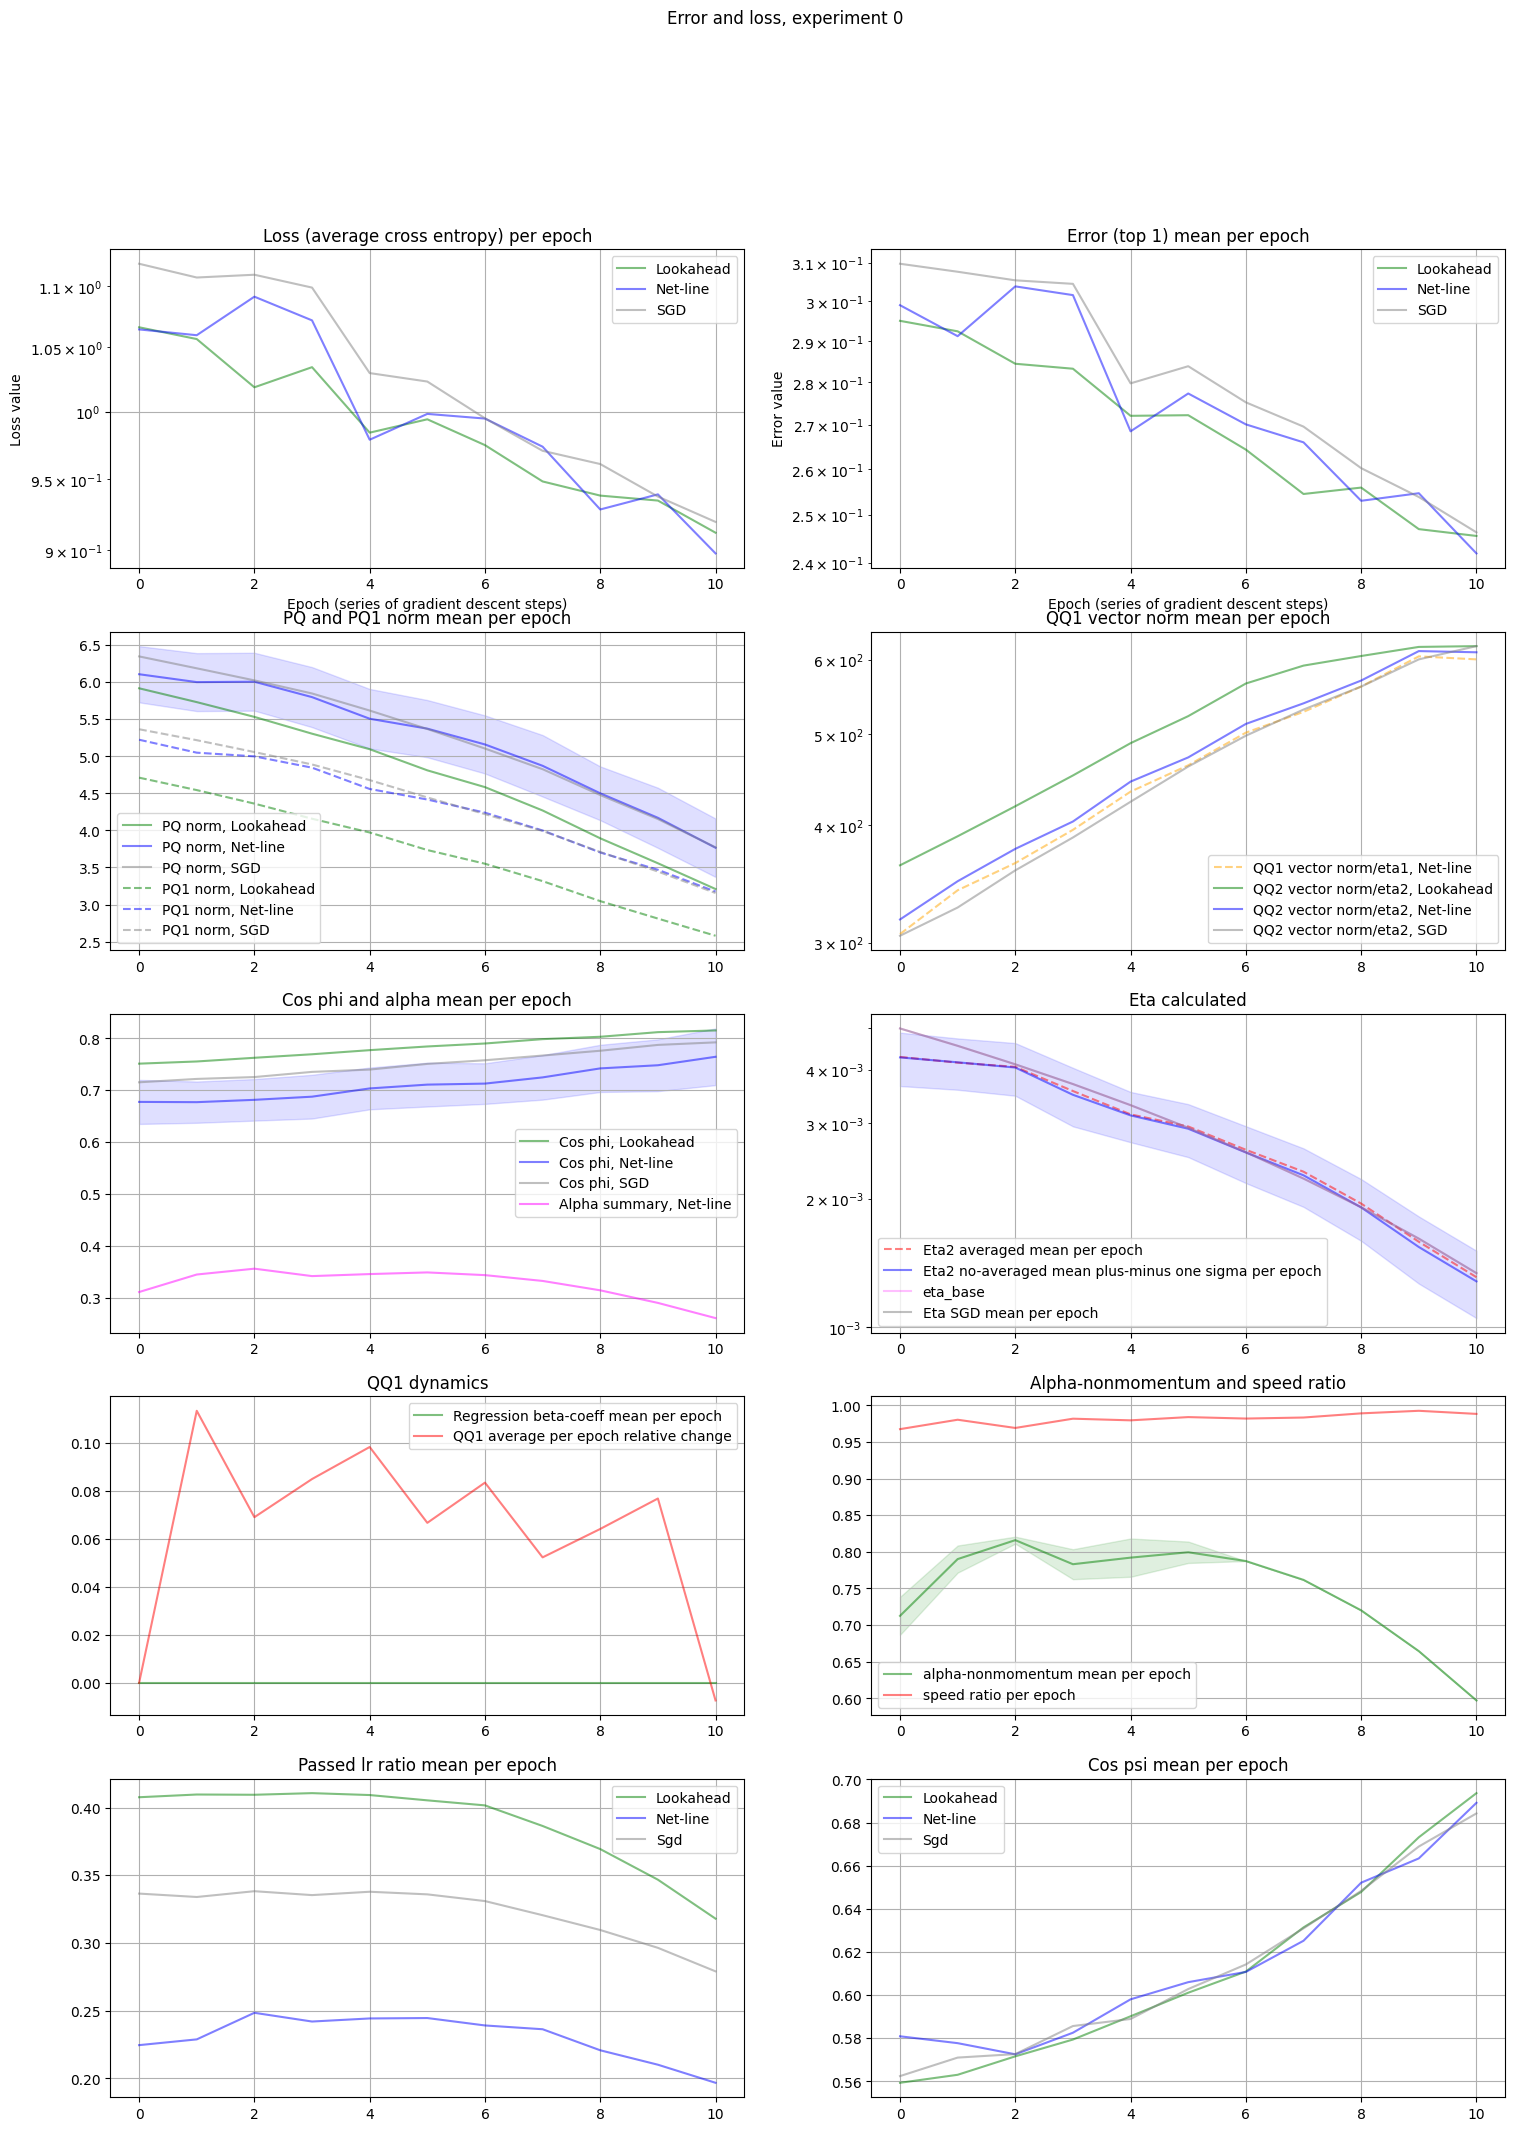

Experiment=0, sgd=0.7536949932575225/0.7536949932575225, net-line=0.7580795586109161/0.7580795586109161, lookahead=0.7544463455677033/0.7544463455677033, alpha_nomomentum=0.5970709472894669, cos_phi=0.7646254897117615/0.7646254897117615


In [ ]:
meta = MetaData(batch_size = BATCH_SIZE, output_dim=OUTPUT_DIM, device=DEVICE)

'''
0-num of experiment; 1-epoch;
2-net: 0-Lookahead, 1-Net-line 2step, 2-SGD
3-param: 0-test accuracy (Top-1), 1-test errror (cross-entropy), 2-time per step, 3 - qq_norm_test,
4 - pq_norm, 5 - cos_phi, 6 - eta2, 7 - pq1_norm, 8 - passed lr ratio, 9 - alpha_nomomentum, 10 - qq_full/eta2,
11 - lr0, 12 - pq_norm sdev, 13 - cos_phi  sdev, 14 - alpha_nomomentum sdev, 15 - alpha,
16 - speeds ratio, 17 - cos_psi, 18 - None, 19 - None, 20 - None, 21 - eta2_pre, 22 - eta2_pre_var
'''
experimental_results = np.zeros((EXPERIMENTS, EPOCHS_PER_EXPERIMENT, 3, 24))

for experiment in range(EXPERIMENTS):

    #Lookahead
    #net_lookahead = make_resnet18v2(3, OUTPUT_DIM).to(DEVICE)
    loss_lookahead = nn.CrossEntropyLoss()
    opt_sgd_lookahead = optim.SGD(net_lookahead.parameters(), 0.02, momentum=0.9, weight_decay=5e-3)
    for group in opt_sgd_lookahead.param_groups:
        group.setdefault('initial_lr', group['lr'])
    opt_lookahead = Lookahead(opt_sgd_lookahead)
    schd_lookahead = optim.lr_scheduler.CosineAnnealingLR(opt_lookahead, T_max=EPOCHS_PER_EXPERIMENT) #, last_epoch=START_EPOCH - 1)

    #Net-line 2step
    max_lr = 0.02
    EPOCHS_WARMUP = 3
    SAMPLE_PROB = 0.05 #0.025 if OUTPUT_DIM < 50 else 0.05
    #averaging_check_base = 0.01 #, averaging_check_mid = 0.5, 0.1 #0.75 if OUTPUT_DIM < 50 else 0.1
    snl_momentum = 0.9
    snl_foreach = True

    #snl_net = copy.deepcopy(net_lookahead)
    snl_opt = optim.SGD(snl_net.parameters(), weight_decay=5e-3, lr=max_lr, momentum=snl_momentum)
    snl_sch = NetLineStepLR(snl_net, snl_opt, meta, foreach=snl_foreach, loss_fn=nn.CrossEntropyLoss(reduction='mean'))
    snl_sch.do_shorten_lr_for_momentum = False
    snl_sch.lr_averaging_queue_size = 100 #300
    snl_sch.alpha_nomomentum_queue_size = 20 #30
    snl_sch.alpha_nomomentum_max = torch.tensor(2.0).to(meta.device)
    snl_sch.la_alpha = 1.0
    snl_sch._flag_sgd_patched_for_secondstep = True
    #snl_sch._total_la_steps = 10

    snl_sch.init_params()
    #snl_sch.init_lookahead()
    snl_sch.init_eta_averaging()
    snl_sch.init_alpha_nomomentum_averaging()

    #Sgd scheduled lr
    #net_sgd = copy.deepcopy(net_lookahead)
    loss_sgd = nn.CrossEntropyLoss()
    opt_sgd = optim.SGD(net_sgd.parameters(), 0.02, momentum=0.9, weight_decay=5e-3)
    for group in opt_sgd.param_groups:
        group.setdefault('initial_lr', group['lr'])
    schd_sgd = optim.lr_scheduler.CosineAnnealingLR(opt_sgd, T_max=EPOCHS_PER_EXPERIMENT) #, last_epoch=START_EPOCH - 1)

    alpha_momentum_base = math.sqrt(1-snl_momentum**2)
    if START_EPOCH > 0:
        for _ in range(START_EPOCH):
            schd_sgd.step()
            schd_lookahead.step()

    epochs_sampling = int(EPOCHS_PER_EXPERIMENT*3/4) #1/2 3/4 5/8 11/16
    epochs_wide = int(EPOCHS_PER_EXPERIMENT*3/4)
    epochs_anysampling = int(EPOCHS_PER_EXPERIMENT*7/8) #epochs_cosine + int((EPOCHS_PER_EXPERIMENT-epochs_cosine)/2)
    switch_epoch = 146000 #epochs_pretail #epochs_cosine - 4

    for epoch in range(START_EPOCH, EPOCHS_PER_EXPERIMENT):
        if DO_LOAD == False and SAVE_EPOCH == epoch and experiment == 0:
            torch.save(net_lookahead.state_dict(), 'run_data/'+SAVE_PREFIX+'_lookahead.pth')
            torch.save(snl_net.state_dict(), 'run_data/'+SAVE_PREFIX+'_snl.pth')
            torch.save(net_sgd.state_dict(), 'run_data/'+SAVE_PREFIX+'_sgd.pth')

        snl_sch.alpha_momentum = alpha_momentum_base
        snl_sch._flag_check_no_backstep = False
        if epoch < epochs_wide:
            snl_sch.lr_averaging_check_down = 0.25
            snl_sch.lr_averaging_check_up = 0.25 #0.05
        #elif epoch < epochs_tail:
        #    snl_sch.lr_averaging_check_down = 0.05
        #    snl_sch.lr_averaging_check_up = 0.05
        else:
            snl_sch.lr_averaging_check_down = 0.05
            snl_sch.lr_averaging_check_up = 0.05

        snl_sch.y_part = 0.0 if epoch < switch_epoch else 1.0
        #snl_sch.y_part = 1.0 if epoch < switch_epoch else 0.0
        if (epoch == switch_epoch and epoch > 0):
            snl_sch.init_eta_averaging()
            snl_sch.init_alpha_nomomentum_averaging()

        lr0 = 1e-5
        base_lr = cosine_annealing2_lr(max_lr, 0.0, 0, EPOCHS_PER_EXPERIMENT, epoch)
        #SAMPLE_PROB = line_annealing2_lr(0.05, 1.0, epochs_sampling, epochs_sampling + 5, epoch)
        if epoch <= epochs_sampling:
            SAMPLE_PROB = 0.05
        else:
        #    SAMPLE_PROB = 1.0
            SAMPLE_PROB = 0.0
            alpha_nomomentum_nocosine_base = np.average(experimental_results[experiment, epochs_sampling-4:epochs_sampling+1, 1, 9])
            snl_sch.alpha_nomomentum = \
                cosine_annealing2_lr(alpha_nomomentum_nocosine_base, 0.0, epochs_sampling, EPOCHS_PER_EXPERIMENT, epoch)

        mt_alpha, mt_lokah, mt_netline, mt_sgd, mt_qqFull, mt_non_passed, mt_alpha_nomomentum, mt_qqRatio,\
            mt_qq, mt_pq, mt_pq1, mt_phi, mt_psi, mt_eta2, mt_eta2_pre = get_meters(15)

        mt_lokah_pq, mt_lokah_pq1, mt_lokah_phi, mt_lokah_psi, mt_lokah_qqFull, mt_lokah_non_passed = get_meters(6)
        mt_sgd_pq, mt_sgd_pq1, mt_sgd_phi, mt_sgd_psi, mt_sgd_qqFull, mt_sgd_non_passed = get_meters(6)

        net_lookahead.train(True)
        snl_net.train(True)
        net_sgd.train(True)

        for train_batch in train_dataloader:
            images, labels = train_batch
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            pp = F.one_hot(labels, meta.output_dim)

            eta_lookahead = opt_lookahead.param_groups[0]['lr']
            logging.info("####Step with lookahead, eta={}".format(eta_lookahead))
            ns_start = time.time_ns()
            logits0 = net_lookahead.forward(images)
            with torch.no_grad():
                qq0 = F.softmax(logits0, dim=1)
            loss0 = loss_lookahead(logits0, labels)
            opt_lookahead.zero_grad()
            loss0.backward()
            opt_lookahead.step()
            ns_end = time.time_ns()
            mt_lokah.update(ns_end-ns_start)

            with torch.no_grad():
                logits0_1 = net_lookahead.forward(images)
                qq0_1 = F.softmax(logits0_1, dim=1)
                delta_lookahead_pq, delta_lookahead_q1q, delta_lookahead_pq1 = pp-qq0, qq0_1-qq0, pp-qq0_1
                norm_lookahead_pq, norm_lookahead_q1q, norm_lookahead_pq1 = \
                    norm(delta_lookahead_pq, ord='fro'), norm(delta_lookahead_q1q, ord='fro'), norm(delta_lookahead_pq1, ord='fro')
                cos_lookahead_phi = torch.sum(delta_lookahead_pq*delta_lookahead_q1q)/(norm_lookahead_pq*norm_lookahead_q1q)
                cos_lookahead_psi = torch.sum(delta_lookahead_pq1*delta_lookahead_q1q)/(norm_lookahead_pq1*norm_lookahead_q1q)
                non_passed_lookahead = 1.0-torch.sqrt((1.0 - cos_lookahead_phi**2)/(1.0 - cos_lookahead_psi**2))*(cos_lookahead_psi/cos_lookahead_phi)
                
                mt_lokah_pq.update(norm_lookahead_pq)
                mt_lokah_pq1.update(norm_lookahead_pq1)
                mt_lokah_qqFull.update(norm_lookahead_q1q/eta_lookahead)
                mt_lokah_phi.update(cos_lookahead_phi)
                mt_lokah_psi.update(cos_lookahead_psi)
                mt_lokah_non_passed.update(non_passed_lookahead)

            logging.info("####Step with net-line 2step")
            is_sample_step = epoch < EPOCHS_WARMUP or snl_sch._alpha_nomomentum_queue_pos_cyclic == False or np.random.binomial(n=1, p=SAMPLE_PROB) == 1
            if is_sample_step:
                snl_opt.param_groups[0]['lr'] = base_lr
            else:
                snl_opt.param_groups[0]['lr'] = lr0

            ns_start = time.time_ns()
            step_result = snl_sch.step(labels, images, is_sample_step = is_sample_step)
            ns_end = time.time_ns()
            mt_netline.update(ns_end-ns_start)

            snl_eta1_fact = snl_opt.param_groups[0]['lr']

            with torch.no_grad():
                logitsNL_1 = snl_net.forward(images)
                qqNL_1 = F.softmax(logitsNL_1, dim=1)
                delta_nl_q1q, delta_nl_pq1 = qqNL_1-step_result.qq0, pp-qqNL_1
                norm_nl_q1q, norm_nl_pq1 = norm(delta_nl_q1q, ord='fro'), norm(delta_nl_pq1, ord='fro')
                velocity_ratio_x = (step_result.qq_norm/snl_eta1_fact)/(norm_nl_q1q/step_result.eta)
                cos_psi = torch.sum(delta_nl_pq1*delta_nl_q1q)/(norm_nl_q1q*norm_nl_pq1)
                non_passed_nl = 1.0-torch.sqrt((1.0 - step_result.cos_phi**2)/(1.0 - cos_psi**2))*(cos_psi/step_result.cos_phi)

            mt_non_passed.update(non_passed_nl)
            mt_pq.update(step_result.pq_norm)
            mt_pq1.update(norm_nl_pq1)
            mt_qq.update(step_result.qq_norm/snl_eta1_fact)
            mt_qqFull.update(norm_nl_q1q/step_result.eta)
            mt_qqRatio.update(velocity_ratio_x)
            mt_phi.update(step_result.cos_phi)
            mt_psi.update(cos_psi)
            mt_eta2.update(step_result.eta)
            mt_eta2_pre.update(step_result.eta2_pre)
            mt_alpha.update(step_result.alpha)
            mt_alpha_nomomentum.update(step_result.alpha_nomomentum)

            eta_sgd = opt_sgd.param_groups[0]['lr']
            logging.info("####Step with SGD, eta={}".format(opt_sgd.param_groups[0]['lr']))
            ns_start = time.time_ns()
            logits1 = net_sgd.forward(images)
            with torch.no_grad():
                qq1 = F.softmax(logits1, dim=1)
            loss1 = loss_sgd(logits1, labels)
            opt_sgd.zero_grad()
            loss1.backward()
            opt_sgd.step()
            ns_end = time.time_ns()
            mt_sgd.update(ns_end-ns_start)

            with torch.no_grad():
                logits1_1 = net_sgd.forward(images)
                qq1_1 = F.softmax(logits1_1, dim=1)
                delta_sgd_pq, delta_sgd_q1q, delta_sgd_pq1 = pp-qq1, qq1_1-qq1, pp - qq1_1
                norm_sgd_pq, norm_sgd_q1q, norm_sgd_pq1 = \
                    norm(delta_sgd_pq, ord='fro'), norm(delta_sgd_q1q, ord='fro'), norm(delta_sgd_pq1, ord='fro')
                cos_sgd_phi = torch.sum(delta_sgd_pq*delta_sgd_q1q)/(norm_sgd_pq*norm_sgd_q1q)
                cos_sgd_psi = torch.sum(delta_sgd_pq1*delta_sgd_q1q)/(norm_sgd_pq1*norm_sgd_q1q)
                non_passed_sgd = 1.0-torch.sqrt((1.0 - cos_sgd_phi**2)/(1.0 - cos_sgd_psi**2))*(cos_sgd_psi/cos_sgd_phi)

                mt_sgd_pq.update(norm_sgd_pq)
                mt_sgd_pq1.update(norm_sgd_pq1)
                mt_sgd_qqFull.update(norm_sgd_q1q/eta_sgd)
                mt_sgd_phi.update(cos_sgd_phi)
                mt_sgd_psi.update(cos_sgd_psi)
                mt_sgd_non_passed.update(non_passed_sgd)

        #look-ahead: qq_norm, pq_norm, cos_phi
        experimental_results[experiment, epoch, 0, 4] = mt_lokah_pq.avg
        experimental_results[experiment, epoch, 0, 5] = mt_lokah_phi.avg
        experimental_results[experiment, epoch, 0, 7] = mt_lokah_pq1.avg
        experimental_results[experiment, epoch, 0, 8] = mt_lokah_non_passed.avg
        experimental_results[experiment, epoch, 0, 17] = mt_lokah_psi.avg
        experimental_results[experiment, epoch, 0, 10] = mt_lokah_qqFull.avg

        #net-line: qq_norm, pq_norm, cos_phi
        experimental_results[experiment, epoch, 1, 3] = mt_qq.avg
        experimental_results[experiment, epoch, 1, 4] = mt_pq.avg
        experimental_results[experiment, epoch, 1, 5] = mt_phi.avg
        experimental_results[experiment, epoch, 1, 6] = mt_eta2.avg
        experimental_results[experiment, epoch, 1, 20] = 0
        experimental_results[experiment, epoch, 1, 21] = mt_eta2_pre.avg
        experimental_results[experiment, epoch, 1, 22] = mt_eta2_pre.sdev_biased()
        experimental_results[experiment, epoch, 1, 11] = base_lr
        experimental_results[experiment, epoch, 1, 12] = mt_pq.sdev_biased()
        experimental_results[experiment, epoch, 1, 13] = mt_phi.sdev_biased()
        experimental_results[experiment, epoch, 1, 14] = mt_alpha_nomomentum.sdev_biased()
        experimental_results[experiment, epoch, 1, 15] = mt_alpha.avg

        experimental_results[experiment, epoch, 1, 7] = mt_pq1.avg
        experimental_results[experiment, epoch, 1, 8] = mt_non_passed.avg
        experimental_results[experiment, epoch, 1, 9] = mt_alpha_nomomentum.avg
        experimental_results[experiment, epoch, 1, 10] = mt_qqFull.avg
        velocity_ratio = mt_qqRatio.avg
        experimental_results[experiment, epoch, 1, 16] = velocity_ratio
        experimental_results[experiment, epoch, 1, 17] = mt_psi.avg
        experimental_results[experiment, epoch, 1, 18] = 0
        experimental_results[experiment, epoch, 1, 19] = 0

        #sgd: qq_norm, pq_norm, cos_phi
        experimental_results[experiment, epoch, 2, 4] = mt_sgd_pq.avg
        experimental_results[experiment, epoch, 2, 5] = mt_sgd_phi.avg
        experimental_results[experiment, epoch, 2, 7] = mt_sgd_pq1.avg
        experimental_results[experiment, epoch, 2, 8] = mt_sgd_non_passed.avg
        experimental_results[experiment, epoch, 2, 17] = mt_sgd_psi.avg
        experimental_results[experiment, epoch, 2, 10] = mt_sgd_qqFull.avg

        #timing
        experimental_results[experiment, epoch, 0, 2] = mt_lokah.avg
        experimental_results[experiment, epoch, 1, 2] = mt_netline.avg
        experimental_results[experiment, epoch, 2, 2] = mt_sgd.avg

        # testing loop 0-Lookahead, 1-Net-line 2step, 2-SGD
        opt_lookahead._backup_and_load_cache()
        acc0, loss0 = test_loop(net_lookahead, test_dataloader, DEVICE)
        opt_lookahead._clear_and_load_backup()
        experimental_results[experiment, epoch, 0, 0] = acc0
        experimental_results[experiment, epoch, 0, 1] = loss0

        #snl_sch._backup_and_load_cache()
        acc1, loss1 = test_loop(snl_net, test_dataloader, DEVICE)
        #snl_sch._clear_and_load_backup()
        experimental_results[experiment, epoch, 1, 0] = acc1
        experimental_results[experiment, epoch, 1, 1] = loss1

        acc2, loss2 = test_loop(net_sgd, test_dataloader, DEVICE)
        experimental_results[experiment, epoch, 2, 0] = acc2
        experimental_results[experiment, epoch, 2, 1] = loss2
        experimental_results[experiment, epoch, 2, 6] = schd_sgd.get_last_lr()[0]
        experimental_results[experiment, epoch, 2, 11] = 0
        experimental_results[experiment, epoch, 2, 12] = 0

        schd_sgd.step()
        schd_lookahead.step()

        display.clear_output()
        title="Error and loss, experiment {}".format(experiment)
        experiment_comparison(experimental_results[experiment, START_EPOCH:epoch+1], 0, 100, title=title)

        for exp in range(experiment):
            print("Experiment={}, sgd={}, net-line={}, lookahead={}, cos_phi={}"\
                .format(exp, max(experimental_results[exp,  START_EPOCH:EPOCHS_PER_EXPERIMENT, 2, 0])\
                        , max(experimental_results[exp,  START_EPOCH:EPOCHS_PER_EXPERIMENT, 1, 0])\
                        , max(experimental_results[exp,  START_EPOCH:EPOCHS_PER_EXPERIMENT, 0, 0])\
                        , max(experimental_results[exp,  START_EPOCH:EPOCHS_PER_EXPERIMENT, 1, 5])))

        print("Experiment={}, sgd={}/{}, net-line={}/{}, lookahead={}/{}, alpha_nomomentum={}, cos_phi={}/{}"\
            .format(experiment, acc2, max(experimental_results[experiment, START_EPOCH:epoch+1, 2, 0]), \
                    acc1, max(experimental_results[experiment, START_EPOCH:epoch+1, 1, 0]), \
                    acc0, max(experimental_results[experiment, START_EPOCH:epoch+1, 0, 0]) , snl_sch.alpha_nomomentum, \
                    mt_phi.avg, max(experimental_results[experiment, START_EPOCH:epoch+1, 1, 5])))



In [ ]:
print("epochs_sampling={}, epochs_wide={}, switch_epoch={}".format(epochs_sampling, epochs_wide, switch_epoch))

epochs_sampling=45, epochs_wide=45, switch_epoch=146000


In [ ]:
print("Accuracy in the latest experiment, net-line: \n{}".format(experimental_results[experiment, :, 1, 0]))

Accuracy in the latest experiment, net-line: 
[0.20255899 0.3091179  0.37442602 0.40900829 0.42655253 0.42648079
 0.47789581 0.49958546 0.50989716 0.5206513  0.5013353  0.51850885
 0.53018774 0.53907247 0.56927216 0.53898278 0.54137037 0.57671795
 0.55381457 0.5688357  0.59527065 0.59562141 0.59818439 0.6131238
 0.61395687 0.58725486 0.60704719 0.60821707 0.62707868 0.62658442
 0.63127192 0.64549586 0.65401586 0.64143415 0.64493383 0.66635443
 0.66189812 0.66539381 0.6841179  0.69739716 0.6896305  0.69742107
 0.70849211 0.71341079 0.72155413 0.71036153 0.72038226 0.7329261
 0.73716119 0.74776785 0.75803571 0.75621611 0.76309789 0.76395289
 0.7672732  0.7686643  0.77143455 0.77066725 0.77157605 0.76997768]


In [ ]:
print("Accuracy in the latest experiment, SGD: \n{}".format(experimental_results[experiment, :, 2, 0]))

Accuracy in the latest experiment, SGD: 
[0.20301937 0.29659199 0.34008291 0.38758968 0.4103396  0.43184989
 0.46194994 0.48701969 0.46637835 0.4976144  0.50163823 0.5016741
 0.50100446 0.5298569  0.53747808 0.50720264 0.52410116 0.54000916
 0.53015785 0.57244499 0.55670241 0.55770687 0.54838568 0.59171118
 0.59706632 0.56466836 0.58006018 0.60565011 0.61947744 0.59318997
 0.61844109 0.61621891 0.62567961 0.6414202  0.64112923 0.6615334
 0.65650709 0.65078125 0.65222018 0.67151427 0.68849849 0.69197026
 0.70338608 0.69819435 0.71961695 0.70360332 0.71995575 0.71962492
 0.74416255 0.74011679 0.75464963 0.75801379 0.76137994 0.77183315
 0.77145846 0.77413903 0.77500997 0.77448581 0.77474091 0.7748007 ]


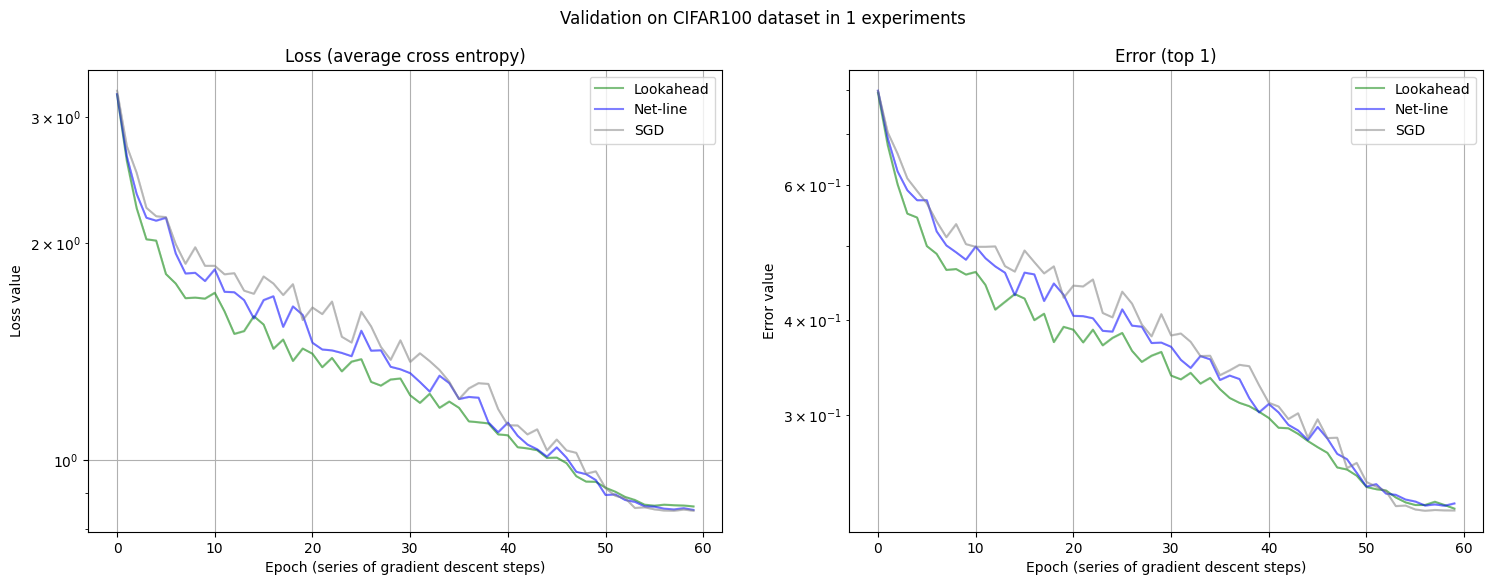

In [ ]:
experimental_mean = np.mean(experimental_results, axis=0)
experimental_std = np.std(experimental_results, axis=0)

display.clear_output()
title2="Validation on CIFAR100 dataset in {} experiments".format(EXPERIMENTS)
experiments_comparison(experimental_mean[0:epoch+1], experimental_std[0:epoch+1], 0, 100, title=title2)


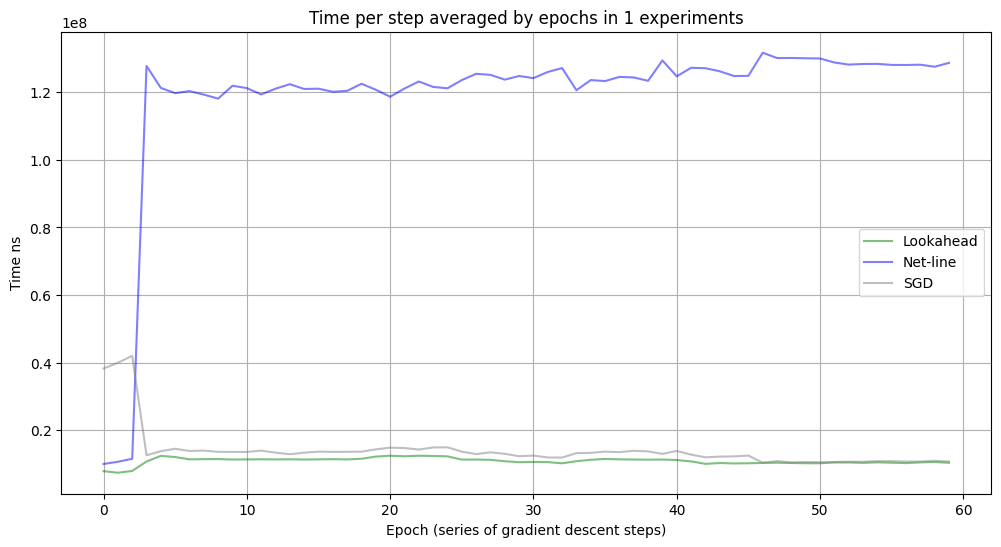

In [ ]:
title2="Time per step averaged by epochs in {} experiments".format(EXPERIMENTS)
timing_comparison(experimental_mean[0:epoch+1], 0, 100, title=title2)

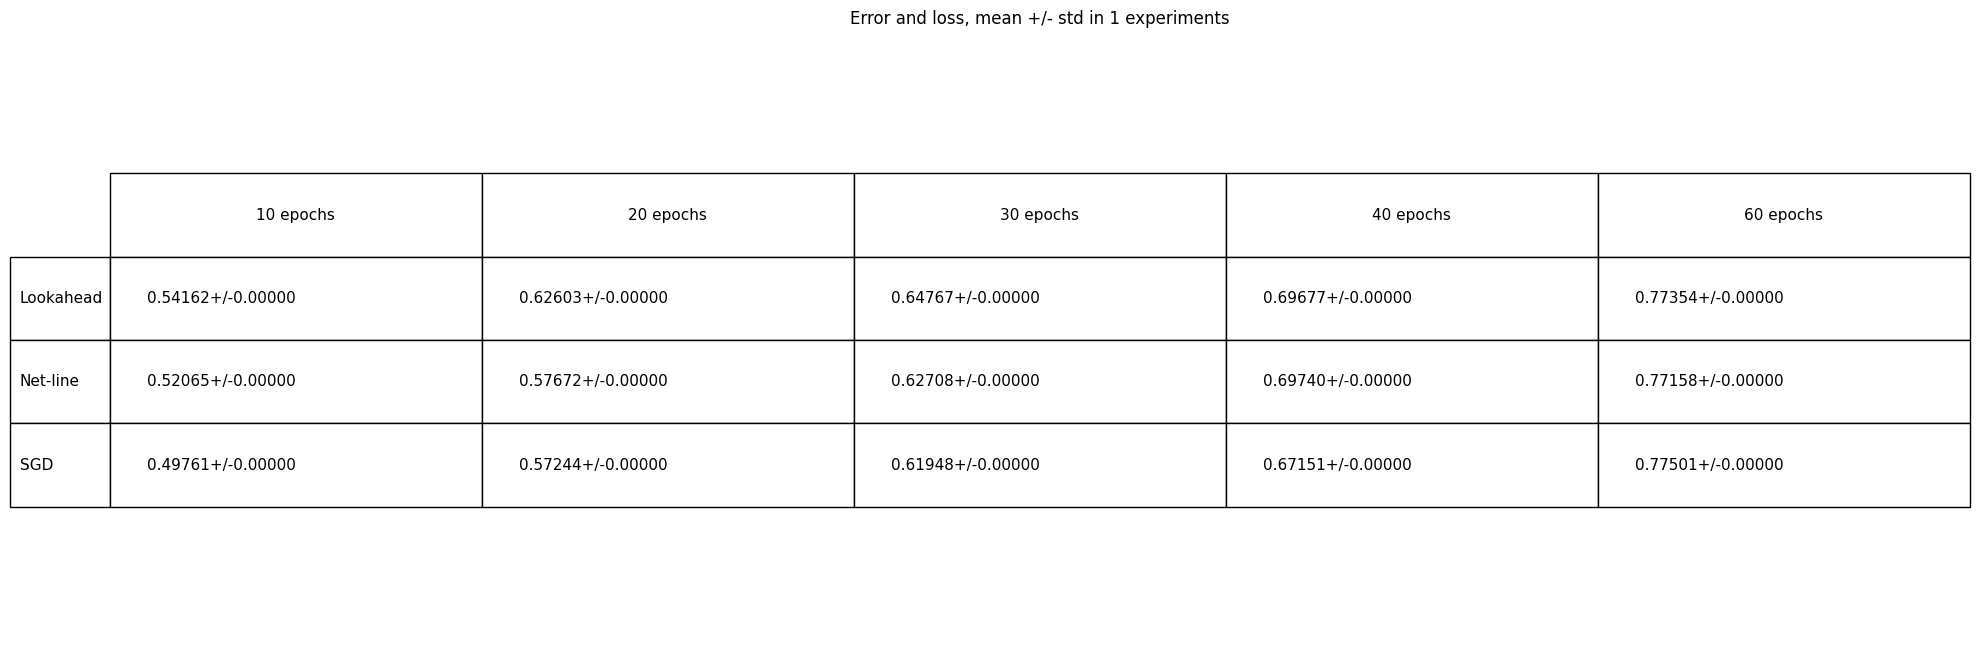

In [ ]:
#experimental_results[2, 0:100, 1, 0]
title3 = "Error and loss, mean +/- std in {} experiments".format(EXPERIMENTS)
accuracy_comparison(experimental_results, 0, EPOCHS_PER_EXPERIMENT, title=title3)